# Spectral Clustering and Centrality-Conformal Analysis

This notebook implements the spectral clustering part of the global MultiSigBERT pipeline, used for our graph-based survival representation framework.  
It combines spectral geometry, graph centrality, and conformal-style calibration.


## Overview of the Pipeline

The notebook follows five main stages:

1. **Data Loading and Standardization**
   - Import patient-level signature coefficients.
   - Extract `sig_*` covariates.
   - Apply z-score normalization.

2. **Graph Construction (kNN)**
   - Build an approximate k-nearest neighbor graph using `PyNNDescent`.
   - Restrict analysis to the largest connected component.

3. **Geometric Representation**
   - Compute geodesic distances (shortest paths).
   - Apply Multidimensional Scaling (MDS) on the geodesic metric.

4. **Spectral Clustering**
   - Convert distances into an RBF affinity matrix.
   - Perform spectral clustering on the affinity graph.
   - Assign cluster labels to patients.

5. **Centrality-Conformal Analysis**
   - Split the dataset into training and calibration subsets.
   - Compute graph centralities (stationary, PageRank, or eigenvector).
   - Inject calibration nodes into the training graph.
   - Compare centrality distributions (train vs calibration).


## Expected Input Format

The CSV dataset must contain:

- `ID` : patient identifier  
- `sig_1, ..., sig_Q` : signature coefficients  
- `event` : binary indicator (1 = death, 0 = censored)  
- `time` : survival time in days  

All signature features are automatically detected via the `sig_` prefix.


## Reproducibility

- All random procedures use a fixed `random_state`.
- The spectral and conformal components are fully deterministic conditional on the seed.
- The notebook is modular: each section relies on reusable Python functions defined above.


## Outputs

The notebook produces:

- Spectral cluster assignments (`cluster_spectral`)
- MDS low-dimensional embeddings
- RBF affinity matrix and bandwidth parameter
- Centrality distributions (training vs injected calibration)
- Diagnostic visualizations


This notebook is designed to be fully self-contained and directly executable once the dataset path is specified.

In [12]:
import numpy as np
import pandas as pd
from spectral_cluster_pkg import *

In [13]:
# ----------------------------
# 1) Hyperparameters
# ----------------------------
N_NEIGHBORS = 15
N_Clusters = 3
RANDOM_STATE = 177

CALIBRATION_FRACTION = 0.30
ALPHA_FIT = 0.05
E_KAPPA = 0.5
CENTRALITY_METHOD = "stationary"
K_INJECT = 50

In [14]:
# ----------------------------
# 2) Load and standardize data
# ----------------------------
CSV_PATH = "df_study_L36_w12.csv"

X, scaler, signature_columns = load_signature_dataset(
    csv_path=CSV_PATH,
    verbose=True
)

df = pd.read_csv(CSV_PATH)
n_patients = X.shape[0]

Number of patients: 2533
Number of signature features: 756


Building kNN graph...
Number of connected components: 1
Largest component size: 2533 / 2533

Cluster distribution:
0     724
1    1726
2      83
Name: count, dtype: int64

Preview of key columns:


,ID,cluster_spectral,event,time
0,r-61126490,1,True,2.0
1,r-54497886,1,True,2.0
2,r-81181138,1,True,2.0
3,r-48531215,0,False,2.0
4,r-56537286,0,False,3.0


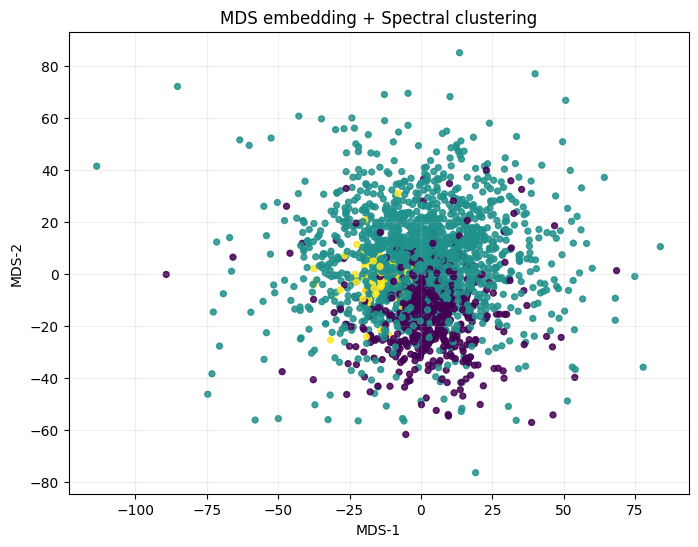

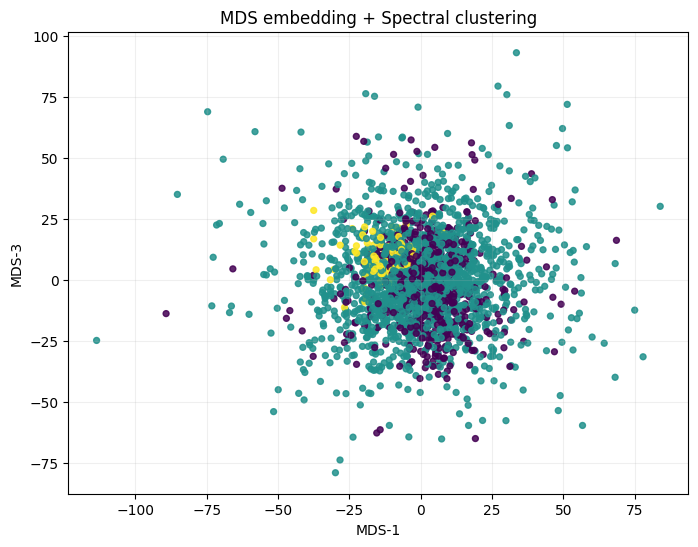

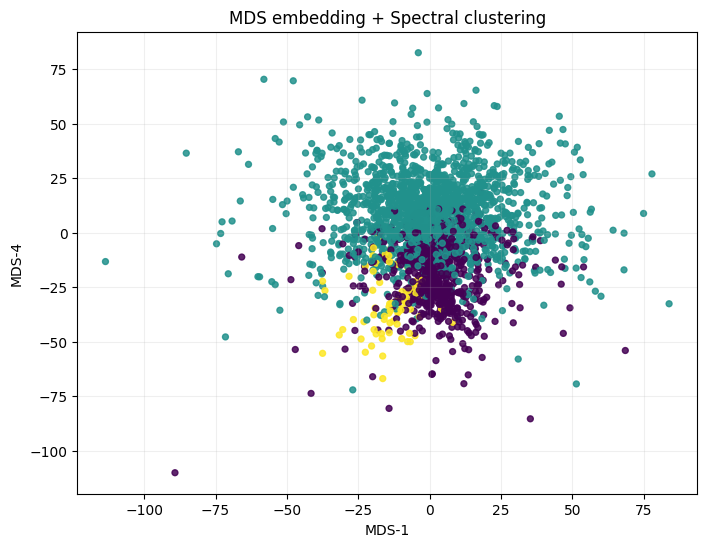

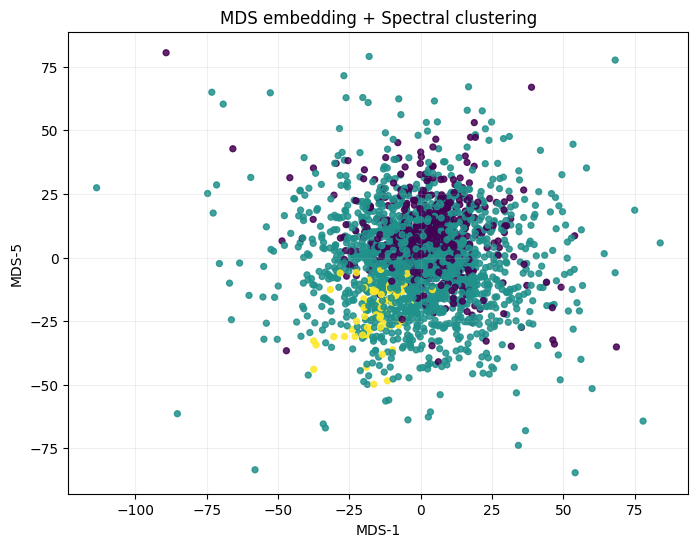

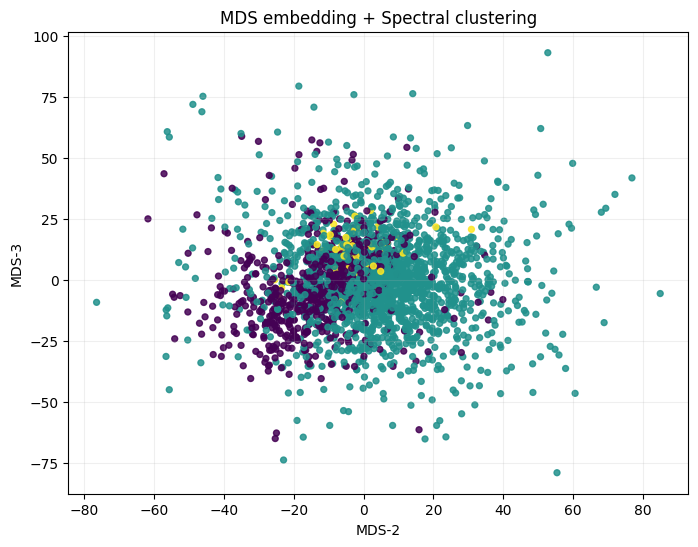

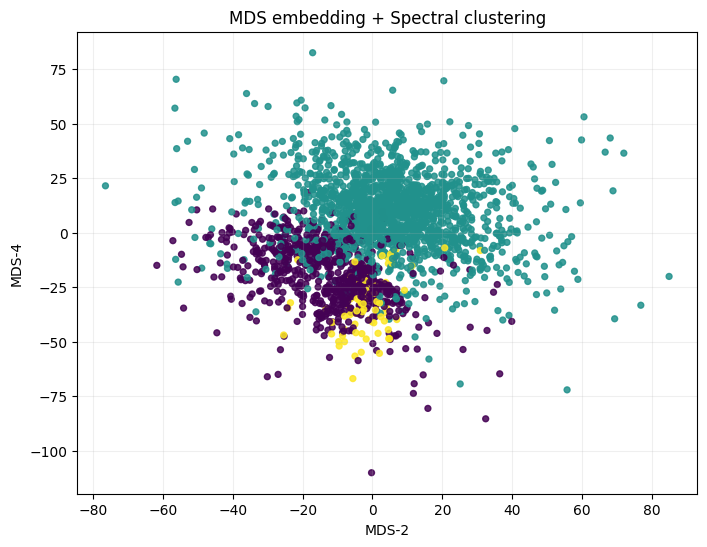

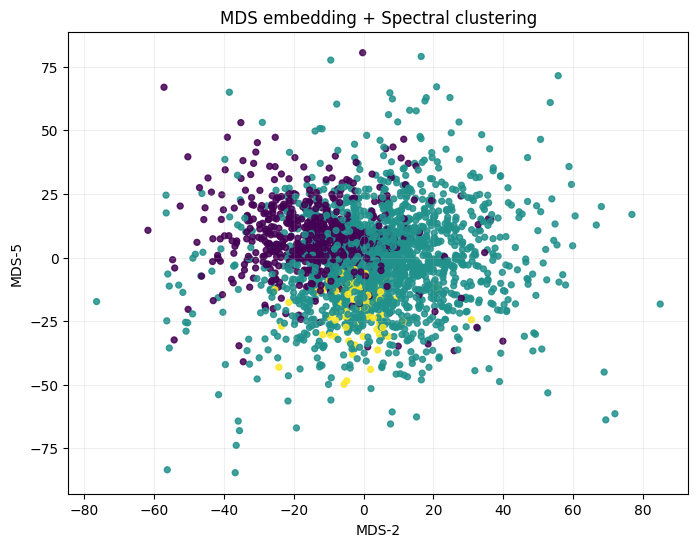

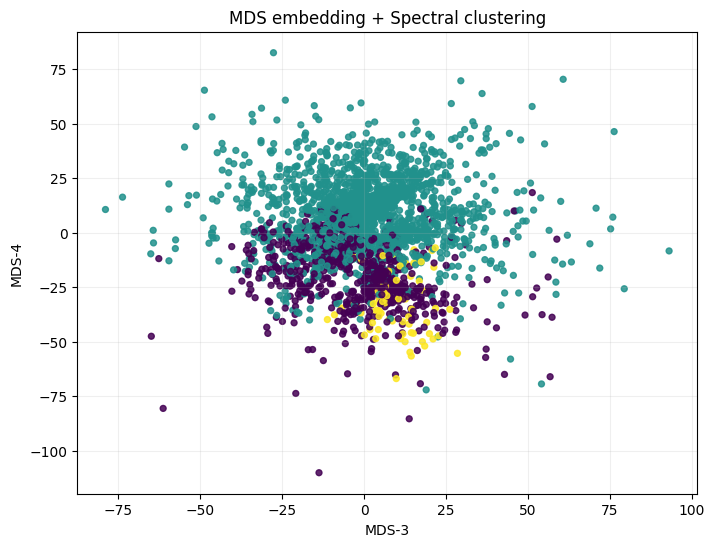

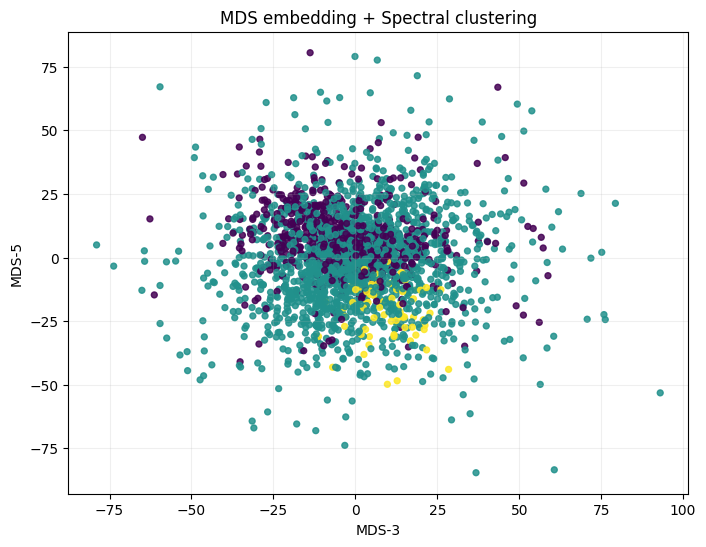

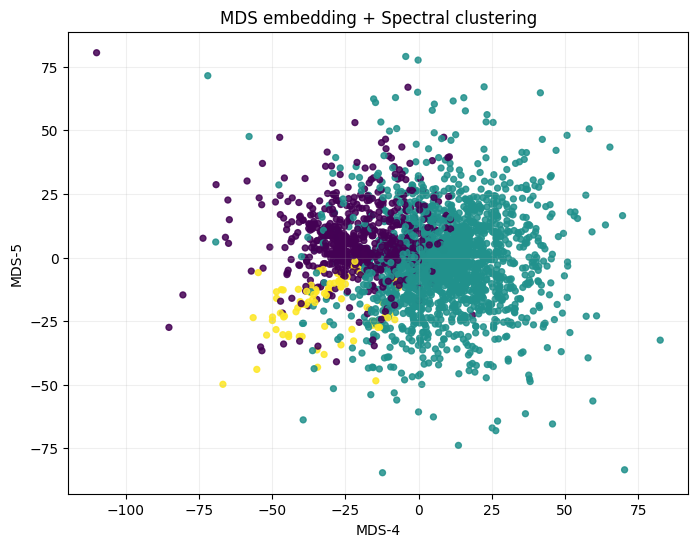

In [16]:
# ----------------------------
# 3) Global spectral learning
# ----------------------------
labels_spectral, Y, A, sigma, df_clusters = global_spectral_learning(
    X=X,
    df=df,
    n_neighbors=N_NEIGHBORS,
    n_clusters=N_Clusters,
    n_mds_components=5,
    random_state=RANDOM_STATE,
    verbose=True
)

In [17]:
# ----------------------------
# 4) Export clustered dataframe
# ----------------------------
df_clusters.to_csv("./df_cluster_L36w12.csv", index=False)
print("Clustered dataframe exported: df_cluster_L36w12.csv")

Clustered dataframe exported: df_cluster_L36w12.csv


In [18]:
# ----------------------------
# 5) Train / Calibration split
# ----------------------------
train_idx, cal_idx = split_train_calibration(
    n_samples=n_patients,
    calibration_fraction=CALIBRATION_FRACTION,
    random_state=RANDOM_STATE,
    stratify_labels=labels_spectral
)

In [19]:
# ----------------------------
# 6) Extract training subgraph
# ----------------------------
W_full = A
W_train = extract_train_subgraph(W_full, train_idx)

In [20]:
# ----------------------------
# 7) Compute train centralities
# ----------------------------
cent_train, deg_sum_train = compute_train_centrality(
    W_train=W_train,
    method=CENTRALITY_METHOD
)

In [21]:
# ----------------------------
# 8) Compute calibration centralities (injected)
# ----------------------------
cent_cal_injected = compute_calibration_centralities(
    cal_idx=cal_idx,
    W_full=W_full,
    W_train=W_train,
    train_idx=train_idx,
    X=X,
    sigma_aff=sigma,
    method=CENTRALITY_METHOD,
    deg_sum_train=deg_sum_train,
    k_inject=K_INJECT,
    use_full_row_neighbors=True
)

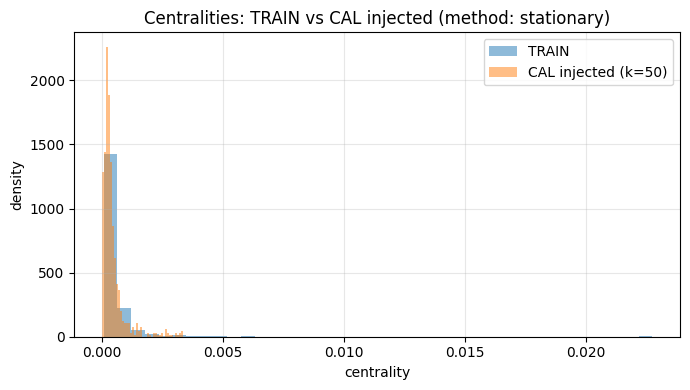

In [22]:
# ----------------------------
# 9) Histogram comparison
# ----------------------------
plot_train_vs_calibration_histograms(
    cent_train=cent_train,
    cent_cal=cent_cal_injected,
    method=CENTRALITY_METHOD,
    k_inject=K_INJECT
)